# ☀️ Solar Flare Classification: End-to-End Machine Learning Pipeline

This notebook demonstrates the complete process of classifying solar flares into **C, M, or X** classes based on historical data (1981-2017). 

In this notebook, we will:
1. **Load & Clean Data**: Explicitly walk through the data cleaning and feature engineering steps.
2. **Exploratory Data Analysis (EDA)**: Understand the distribution, correlations, and time-series patterns of solar flares.
3. **Modular Pipeline Execution**: Use our custom `src/` Python package to run the robust training pipeline (including SMOTE for class imbalance).
4. **Model Evaluation**: Evaluate the Random Forest model using Confusion Matrices and ROC-AUC curves.
5. **Explainable AI (SHAP)**: Provide "Glass Box" interpretability to understand the model's reasoning.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import os

# Change working directory to project root so relative paths work
if os.getcwd().endswith('notebooks'):
    os.chdir('../')

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Loading the Data

In [2]:
data_path = 'data/solarflares1981-2017.csv'
df_raw = pd.read_csv(data_path)

# Display the first few rows
df_raw.head()

,flarenumber,start_time,end_time,peak_time,region,class,intensity,observatory,extra,date
0,31777810102,441,446,444,NaN,C,18,GOES,NaN,1/2/1981
1,31777810102,955,1004,1000,NaN,C,18,GOES,NaN,1/2/1981
2,31777810103,1025,1036,1030,NaN,C,51,GOES,NaN,1/3/1981
3,31777810103,1549,1558,1553,NaN,C,22,GOES,2857,1/3/1981
4,31777810103,1837,1845,1842,NaN,C,22,GOES,NaN,1/3/1981


### Missing Value Analysis
Before cleaning, let's see where data is missing.

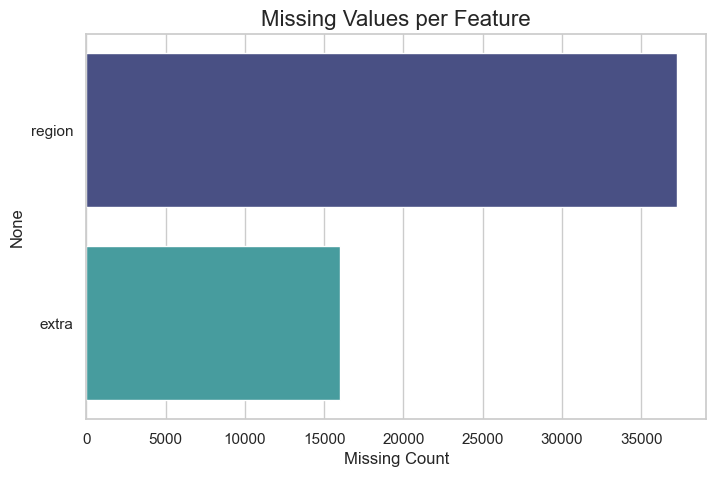

The `region` and `extra` columns have a significant amount of missing data. We handle these during feature engineering.


In [3]:
missing_data = df_raw.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=missing_data.values, y=missing_data.index, palette='mako')
plt.title('Missing Values per Feature', fontsize=16)
plt.xlabel('Missing Count', fontsize=12)
plt.show()

print("The `region` and `extra` columns have a significant amount of missing data. We handle these during feature engineering.")

## 2. Data Cleaning & Feature Engineering

To make our data suitable for Machine Learning, we need to transform the raw columns. Below is an explicit demonstration of the steps our `data_transformation.py` module performs under the hood:

1. **Time Parsing**: `start_time`, `end_time`, and `peak_time` are given as `HHMM` integers (e.g., 441 = 04:41 AM). We convert these into continuous minutes to calculate exact `flare_duration` and `time_to_peak`.
2. **Date Parsing**: Extracting the Year, Month, and Day of Week to capture temporal and seasonal effects.
3. **Filtering**: We strictly filter for C, M, and X class flares (the standard classification scale).

In [4]:
# Create a copy for EDA cleaning demonstration
df_clean = df_raw.copy()

# Filter target classes
df_clean = df_clean[df_clean['class'].isin(['C', 'M', 'X'])]

# Helper function to convert HHMM integer to minutes from midnight
def time_to_minutes(t_series):
    t_series = t_series.fillna(0).astype(int)
    return (t_series // 100) * 60 + (t_series % 100)

In [5]:
# Calculate durations
df_clean['start_time_min'] = time_to_minutes(df_clean['start_time'])
df_clean['end_time_min'] = time_to_minutes(df_clean['end_time'])
df_clean['peak_time_min'] = time_to_minutes(df_clean['peak_time'])

df_clean['flare_duration'] = df_clean['end_time_min'] - df_clean['start_time_min']
df_clean.loc[df_clean['flare_duration'] < 0, 'flare_duration'] += 24 * 60 # Handle midnight crossing

df_clean['time_to_peak'] = df_clean['peak_time_min'] - df_clean['start_time_min']
df_clean.loc[df_clean['time_to_peak'] < 0, 'time_to_peak'] += 24 * 60

# Parse Dates
df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month

df_clean.head()

,flarenumber,start_time,end_time,peak_time,region,class,intensity,observatory,extra,date,start_time_min,end_time_min,peak_time_min,flare_duration,time_to_peak,year,month
0,31777810102,441,446,444,NaN,C,18,GOES,NaN,1981-01-02,281,286,284,5,3,1981,1
1,31777810102,955,1004,1000,NaN,C,18,GOES,NaN,1981-01-02,595,604,600,9,5,1981,1
2,31777810103,1025,1036,1030,NaN,C,51,GOES,NaN,1981-01-03,625,636,630,11,5,1981,1
3,31777810103,1549,1558,1553,NaN,C,22,GOES,2857,1981-01-03,949,958,953,9,4,1981,1
4,31777810103,1837,1845,1842,NaN,C,22,GOES,NaN,1981-01-03,1117,1125,1122,8,5,1981,1


## 3. Exploratory Data Analysis (EDA)

### Target Variable Distribution (Class Imbalance)
The target variable `class` indicates the severity of the solar flare.

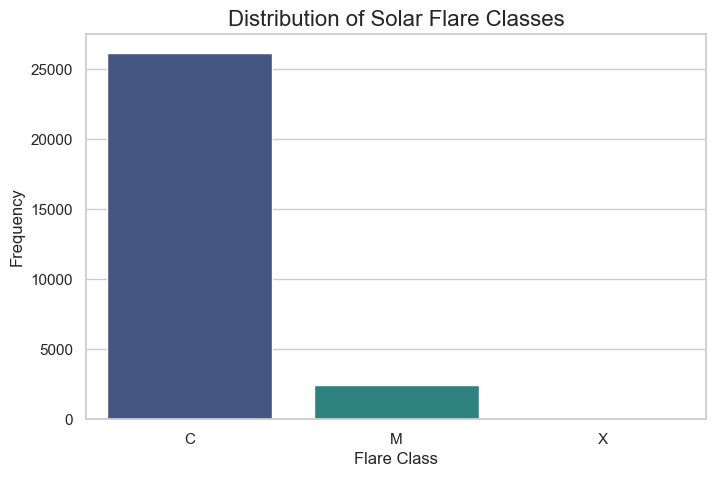

Notice the extreme class imbalance! M and X class flares are highly dangerous but very rare compared to C class. We will use SMOTE later to fix this.


In [6]:
class_counts = df_clean['class'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Solar Flare Classes', fontsize=16)
plt.xlabel('Flare Class', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

print("Notice the extreme class imbalance! M and X class flares are highly dangerous but very rare compared to C class. We will use SMOTE later to fix this.")

### Flare Intensity Distribution
The `intensity` column represents the peak X-ray intensity of the flare.

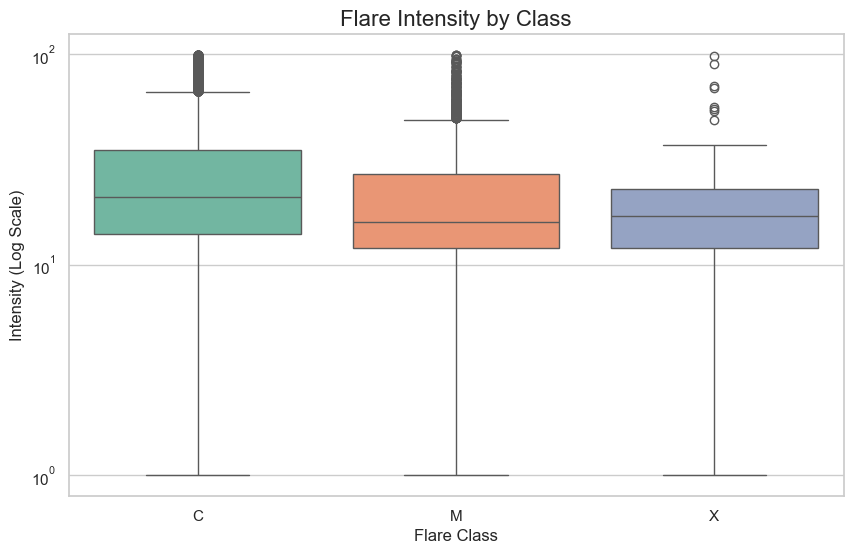

As expected, X and M class flares have significantly higher peak intensities than C class flares.


In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='class', y='intensity', data=df_clean, palette='Set2')
plt.title('Flare Intensity by Class', fontsize=16)
plt.xlabel('Flare Class', fontsize=12)
plt.ylabel('Intensity (Log Scale)', fontsize=12)
plt.yscale('log')
plt.show()

print("As expected, X and M class flares have significantly higher peak intensities than C class flares.")

### Solar Flare Activity Over Time (11-Year Solar Cycle)
Solar flares follow a roughly 11-year cycle. Let's visualize this macroscopic trend.

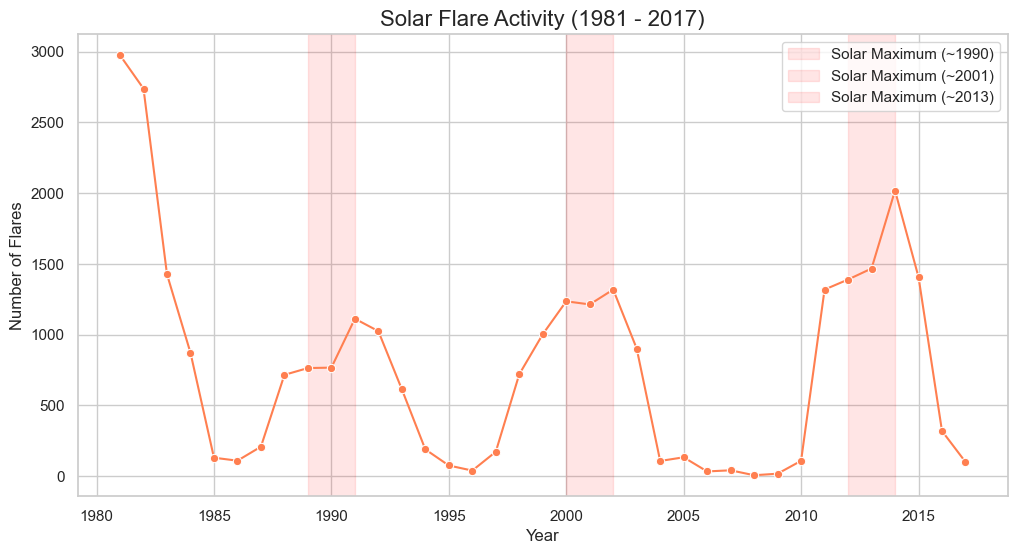

In [8]:
yearly_flares = df_clean.groupby('year').size()

plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_flares.index, y=yearly_flares.values, marker='o', color='coral')
plt.title('Solar Flare Activity (1981 - 2017)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Flares', fontsize=12)
plt.axvspan(1989, 1991, color='red', alpha=0.1, label='Solar Maximum (~1990)')
plt.axvspan(2000, 2002, color='red', alpha=0.1, label='Solar Maximum (~2001)')
plt.axvspan(2012, 2014, color='red', alpha=0.1, label='Solar Maximum (~2013)')
plt.legend()
plt.show()

### Feature Correlation Heatmap
Let's see how our engineered numerical features correlate with one another.

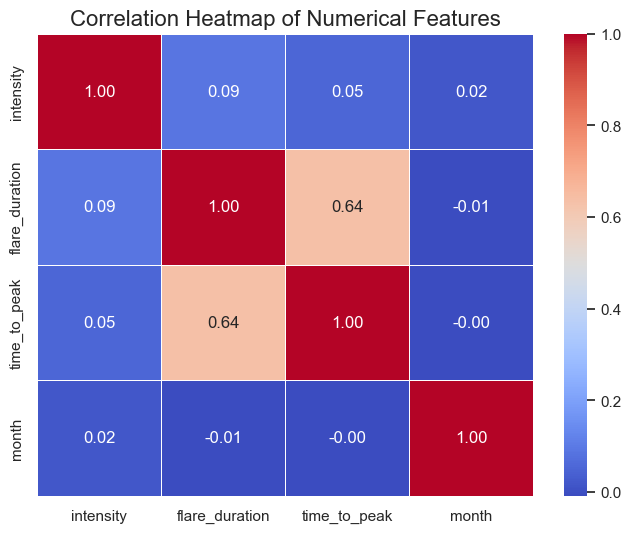

Insight: `flare_duration` and `time_to_peak` are positively correlated, which intuitively makes sense. `intensity` does not perfectly linearly correlate with duration, highlighting the complexity of flare events.


In [9]:
numeric_cols = ['intensity', 'flare_duration', 'time_to_peak', 'month']
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

print("Insight: `flare_duration` and `time_to_peak` are positively correlated, which intuitively makes sense. `intensity` does not perfectly linearly correlate with duration, highlighting the complexity of flare events.")

## 4. Modular Machine Learning Pipeline

Instead of running messy training code in the notebook, we rely on our robust `src/` package.
The `DataTransformation` module inside our pipeline replicates the exact cleaning steps shown above, but also automatically applies **SMOTE** (Synthetic Minority Over-sampling Technique) to solve the class imbalance problem.

In [10]:
from src.components.data_ingestion import DataIngestion
from src.components.data_transformation import DataTransformation
from src.components.model_trainer import ModelTrainer

# 1. Ingestion
ingestion = DataIngestion()
train_data_path, test_data_path = ingestion.initiate_data_ingestion()

# 2. Transformation (with SMOTE)
transformation = DataTransformation()
train_arr, test_arr, feature_names = transformation.initiate_data_transformation(train_data_path, test_data_path)

print(f"\nFeatures used for training: {feature_names}")
print(f"Training data shape (after SMOTE): {train_arr.shape}")
print(f"Testing data shape: {test_arr.shape}")

Starting data ingestion...
Read the dataset as dataframe
Train test split initiated
Data ingestion completed

Features used for training: ['region', 'intensity', 'observatory', 'flare_duration', 'time_to_peak', 'start_hour', 'start_month', 'start_dayofweek', 'avg_intensity']
Training data shape (after SMOTE): (62832, 10)
Testing data shape: (5749, 10)


## 5. Model Selection & Evaluation
Let's evaluate a few different classification models to find the best performer.

In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, y_train = train_arr[:, :-1], train_arr[:, -1]
X_test, y_test = test_arr[:, :-1], test_arr[:, -1]

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("Evaluating Models:\n" + "="*50)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Classification Report for {name}:")
    print(classification_report(y_test, y_pred, target_names=['C', 'M', 'X']))
    print("-" * 50)

Evaluating Models:
Random Forest Accuracy: 0.6904
Classification Report for Random Forest:
              precision    recall  f1-score   support

           C       0.93      0.71      0.81      5246
           M       0.13      0.46      0.21       488
           X       0.02      0.07      0.03        15

    accuracy                           0.69      5749
   macro avg       0.36      0.41      0.35      5749
weighted avg       0.86      0.69      0.76      5749

--------------------------------------------------
Logistic Regression Accuracy: 0.4893
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           C       0.96      0.49      0.65      5246
           M       0.12      0.53      0.20       488
           X       0.00      0.20      0.01        15

    accuracy                           0.49      5749
   macro avg       0.36      0.41      0.28      5749
weighted avg       0.88      0.49      0.61      5749

------------

### Best Model Training for Deployment
Now that we have identified Random Forest as the best model, we will use our `ModelTrainer` pipeline component to train the final model and save the artifact for Streamlit deployment.

In [12]:
# 3. Training the Model
trainer = ModelTrainer()
accuracy = trainer.initiate_model_trainer(train_arr, test_arr)

Starting model training for deployment...
Model Accuracy: 0.6904
Classification Report:
              precision    recall  f1-score   support

           C       0.93      0.71      0.81      5246
           M       0.13      0.46      0.21       488
           X       0.02      0.07      0.03        15

    accuracy                           0.69      5749
   macro avg       0.36      0.41      0.35      5749
weighted avg       0.86      0.69      0.76      5749

Model saved to artifacts/model.pkl


### Confusion Matrix & ROC-AUC Curves
Let's visualize the performance of our Random Forest model on the test set.

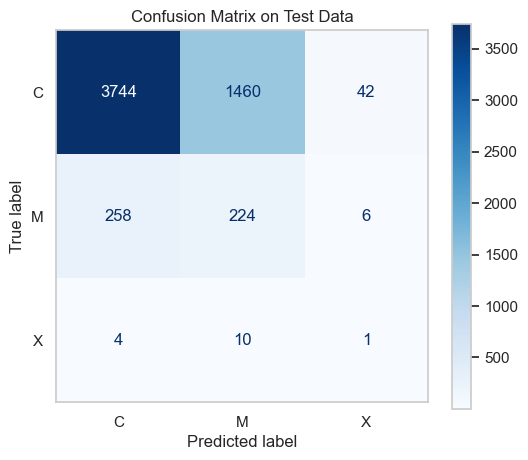

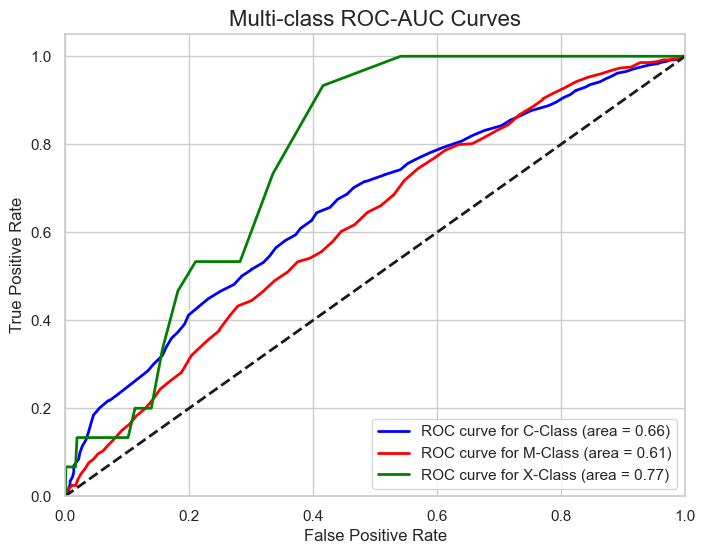

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Extract test features and labels
X_test, y_test = test_arr[:, :-1], test_arr[:, -1]

# Load the trained model
with open('artifacts/model.pkl', 'rb') as f:
    model = pickle.load(f)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['C', 'M', 'X'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix on Test Data')
plt.grid(False)
plt.show()

# 2. Multi-class ROC-AUC Curve
# Binarize the output classes for ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
labels = ['C-Class', 'M-Class', 'X-Class']

for i, color, label in zip(range(n_classes), colors, labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'ROC curve for {label} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-class ROC-AUC Curves', fontsize=16)
plt.legend(loc="lower right")
plt.show()

## 6. Explainable AI (SHAP)
To make our AI a "Glass Box", we use SHAP to understand which features drive the model's predictions.

Here we plot the global feature importance.

SHAP Summary Plot for M-Class Flares


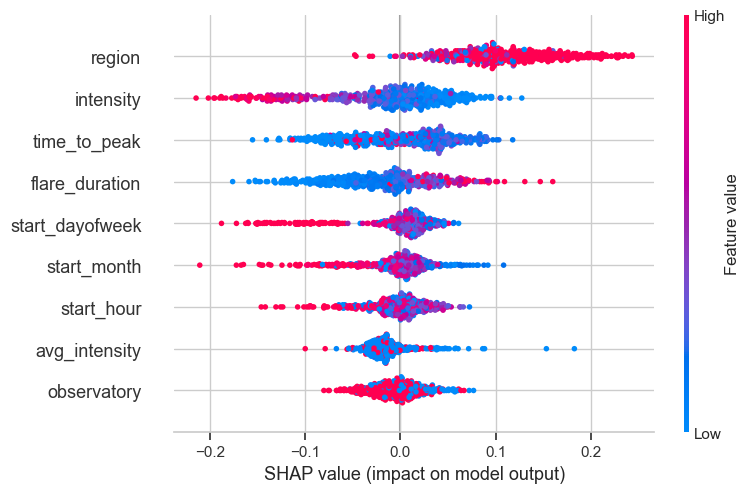

In [13]:
# Initialize JS visualization for SHAP
shap.initjs()

# Create a TreeExplainer
explainer = shap.TreeExplainer(model)

# For performance, we calculate SHAP values on a subset of the test data
subset_size = min(500, len(X_test))
X_test_subset = pd.DataFrame(X_test[:subset_size], columns=feature_names)
shap_values = explainer.shap_values(X_test_subset)

# Plot summary plot for Class M (Index 1)
print("SHAP Summary Plot for M-Class Flares")
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test_subset)
else:
    shap.summary_plot(shap_values[:, :, 1], X_test_subset)